#### Exercise 4 - Starter - Difference-in-Differences

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf 
import seaborn as sns
import matplotlib.pyplot as plt

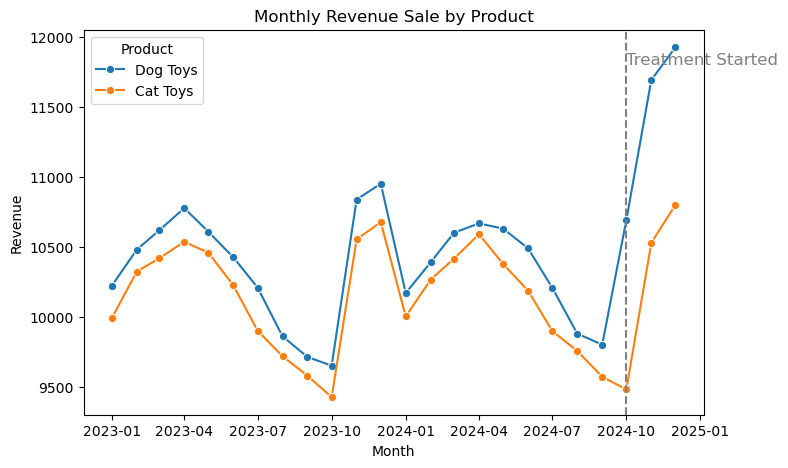

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_months = 24
products = ["Dog Toys", "Cat Toys"]
months = pd.date_range(start="2023-01-01", periods=n_months, freq='MS')

# Marketing event date
event_date = pd.to_datetime('2024-10-01')
model_start_date = '2024-01-01'
model_end_date = '2025-01-01' 


# Create base dataframe
df = pd.DataFrame([(month, product) for month in months for product in products],
                  columns=["Month", "Product"])

# Add month number for seasonality
df["Month_Num"] = df["Month"].dt.month

# Seasonality: smooth wave + December holiday bump
df["Seasonality"] = 500 * np.sin((df["Month_Num"] - 1) / 12 * 2 * np.pi)
df["HolidayBump"] = np.where(df["Month_Num"] >= 11, 1000, 0)

# Add randomness and slight product-level difference
df["BaseRevenue"] = 10000
df["ProductGapBaseline"] = df["Product"].map({"Dog Toys": 200, "Cat Toys": 0})
df["Noise"] = np.random.normal(0, 50, size=len(df))


#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#%%%%%  This is the ground-truth effect of the treatment: 
#%%%%%  an extra $1000 monthly revenue for dog toys in Q4 2024 
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

df['BetterPhotos'] = np.where((df['Product']=='Dog Toys') & (df['Month'] >= event_date), 1000, 0)

# Final revenue
df["Revenue"] = (
    df["BaseRevenue"]
    + df["ProductGapBaseline"]
    + df["Seasonality"]
    + df["HolidayBump"]
    + df["BetterPhotos"]
    + df["Noise"]
)

# Final output DataFrame
df = df[["Month", "Product", "Revenue"]]


# TO-DO: Visualize the time series 
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='Month', y='Revenue', hue='Product', marker='o')
plt.axvline(x=event_date, color='gray', linestyle='--',label='Treatment Introduced')
plt.text(event_date, df['Revenue'].max()*0.99, 'Treatment Started', color='gray',fontsize=12)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Sale by Product')
plt.show()

- Here, we put in other factors such as seasonality, holiday bumps and noise. The ground truth of the photo effect is the extra $1000.

What would happen if we ran the interrupted time series model on dog toys from the previous lesson?

In [4]:
dogs = df[(df['Product']=='Dog Toys') & (df['Month'] >= model_start_date) & (df['Month'] < model_end_date)].copy()

# TO-DO: Estimate an Interrupted Time Series using only data for dog toys 
dogs['trend']=((dogs["Month"].dt.year - event_date.year) * 12
    + (dogs["Month"].dt.month - event_date.month))
dogs['post']=dogs['Month']>=event_date
dogs['trend_post']=dogs['trend']*dogs['post']


formula = 'Revenue~trend+post+trend_post'
model = smf.ols(formula=formula, data=dogs).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     15.53
Date:                Fri, 28 Nov 2025   Prob (F-statistic):            0.00107
Time:                        21:18:34   Log-Likelihood:                -82.522
No. Observations:                  12   AIC:                             173.0
Df Residuals:                       8   BIC:                             175.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     9987.2327    208.732     47.847   

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  res = hypotest_fun_out(*samples, **kwds)


In [6]:
### TO-DO Calculate the average monthly effect from the ITS
beta2=model.params['post[T.True]']
beta3=model.params['trend_post']
subset = dogs.query("post==True and trend >=0")

# its_effect = subset['trend']*beta3+beta2
its_effect=dogs['post']*beta2+dogs['trend_post']*beta3
print(f"Avg Monthly Effect:{its_effect.sum()/dogs['post'].sum() : 0.1f}")

Avg Monthly Effect: 1516.9


- As we can see here, the ITS predicted 1.5k effect, which is higher than the ground truth $1000, due to other factors that we plug in the revenue.

#### Estimate the difference-in-differences model

In [8]:
# TO-DO: Estimate the difference-in-differences model 
df['treated'] = (df['Product']=='Dog Toys').astype(int)
df['post'] = (df['Month']>=event_date).astype(int)
df['post_treated'] = df['treated']*df['post']

subset = df[(df['Month'] >= model_start_date) & (df['Month'] < model_end_date)]
formula = 'Revenue~treated+post+post_treated' 
model = smf.ols(formula, data=subset).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.462
Method:                 Least Squares   F-statistic:                     7.580
Date:                Fri, 28 Nov 2025   Prob (F-statistic):            0.00141
Time:                        21:22:52   Log-Likelihood:                -176.89
No. Observations:                  24   AIC:                             361.8
Df Residuals:                      20   BIC:                             366.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.012e+04    140.326     72.127   

In [10]:
### TO-DO: What is the average monthly effect from the Diff-in-Diff model?  How does it compare to ground truth?
beta3=model.params['post_treated']

did_effect = beta3*subset['post_treated']
print(f"Avg Monthly Effect:{did_effect.sum()/subset['post_treated'].sum() : 0.1f}")

Avg Monthly Effect: 968.7


- Here, the post_treated coeff is much closer to $1000, despite the confidence interval is a bit large, it's statistically significant.